# Algoritmos Variacionais Quânticos

Os algoritmos variacionais surgem como uma resposta direta às limitações do hardware quântico atual (era NISQ). Em vez de executar circuitos profundos e exatos, como em algoritmos do tipo Shor ou Grover, a ideia aqui é usar circuitos curtos e parametrizados, e delegar parte do problema para um otimizador clássico.

A ideia dos VQAs é substituir circuitos fixos por circuitos *parametrizados*, cujas portas de rotação dependem de ângulos ajustáveis. Um otimizador clássico varia esses ângulos iterativamente, usando medições feitas no hardware quântico como sinal de realimentação, até que o circuito produza o resultado desejado. Como circuitos curtos e rasos são menos afetados pelo ruído, essa abordagem consegue extrair informação útil de hardware ruidoso, transformando o problema quântico num problema de otimização clássica.

## Instalação

In [6]:
!pip install qiskit==2.3.0 qiskit-aer==0.17.0 scipy matplotlib pylatexenc --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 89.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.2 MB/s eta 0:00:00


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from itertools import product

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.primitives import StatevectorEstimator, StatevectorSampler
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_aer.noise import NoiseModel, depolarizing_error

import qiskit, qiskit_aer, scipy
print(f"Qiskit {qiskit.__version__} | Aer {qiskit_aer.__version__} | SciPy {scipy.__version__}")

Qiskit 2.3.0 | Aer 0.17.0 | SciPy 1.16.3




O Qiskit 2.x centraliza toda a interação com backends em duas abstrações chamadas *primitivas*.

O **Sampler** executa circuitos e devolve distribuições de probabilidade sobre os resultados de medição, equivalente direto do que fazíamos com `backend.run()`, mas com interface padronizada que funciona em qualquer backend (simulador local, simulador ruidoso, hardware real).

O **Estimator** recebe um circuito $|\psi(\theta)\rangle$ e um observável $H$ expresso como combinação linear de produtos de Pauli, e devolve diretamente o valor esperado:

$$\langle H \rangle_{\theta} = \langle\psi(\theta)|H|\psi(\theta)\rangle$$

Internamente, o Estimator monta os circuitos de medição necessários para cada base de Pauli presente em $H$, executa todas as medições, e retorna o valor esperado já calculado. Para algoritmos variacionais, é exatamente o Estimator que precisamos: ele abstrai o processo de "medir um observável" em uma única chamada de API.

A vantagem arquitetural é que o código que escrevermos funciona de forma idêntica com `StatevectorEstimator` (simulação exata), `AerEstimator` (simulação ruidosa local) ou o `Estimator` do Qiskit Runtime (hardware real na IBM Cloud). Só trocamos qual instância é criada.

## O princípio variacional e o VQE

O **VQE** (*Variational Quantum Eigensolver*) foi proposto por Peruzzo et al. em 2014 para calcular energias de estado fundamental de moléculas usando hardware quântico de pequeno porte. Ele é construído sobre o **princípio variacional** da mecânica quântica:

> Para qualquer estado normalizável $|\psi\rangle$ e qualquer hamiltoniano $H$ com autovalor mínimo $E_0$, vale:
> $$E_0 \leq \langle\psi|H|\psi\rangle$$

A demonstração é direta. Qualquer estado pode ser expandido na base de autoestados $\{|e_k\rangle\}$ de $H$:

$$|\psi\rangle = \sum_k c_k |e_k\rangle, \qquad H|e_k\rangle = E_k|e_k\rangle, \qquad E_0 \leq E_k \text{ para todo } k$$

Calculando o valor esperado:

$$\langle\psi|H|\psi\rangle = \sum_k |c_k|^2 E_k \geq E_0 \sum_k |c_k|^2 = E_0$$

O sinal de igualdade vale se e somente se $|\psi\rangle = |e_0\rangle$, o próprio estado fundamental.

O princípio variacional nos diz que $\langle H\rangle$ é sempre um **limitante superior** para $E_0$. Se conseguirmos minimizar esse valor esperado sobre uma família parametrizada de estados $|\psi(\theta)\rangle$, chegamos à melhor aproximação que a família consegue oferecer para o estado fundamental.

O VQE implementa essa ideia como um loop híbrido:

$$\theta^* = \arg\min_{\theta} \, \mathcal{L}(\theta), \qquad \mathcal{L}(\theta) = \langle\psi(\theta)|H|\psi(\theta)\rangle$$

onde $|\psi(\theta)\rangle$ é o estado preparado pelo circuito quântico parametrizado, e $\mathcal{L}(\theta)$ é calculado via medições no hardware. O otimizador clássico (COBYLA, Adam, L-BFGS-B, etc.) atualiza $\theta$ iterativamente até convergir.

O circuito parametrizado que gera os estados candidatos é chamado de **ansatz** (palavra alemã que significa "suposição" ou "tentativa de solução"). A escolha do ansatz determina o sucesso do VQE: ele precisa ser expressivo o suficiente para representar o estado de interesse, mas raso o suficiente para manter os erros toleráveis.

## Representação do hamiltoniano em base de Pauli

Para calcular $\langle H \rangle$ em um computador quântico, precisamos expressar $H$ de uma forma que seja mensurável com circuitos de medição padrão (medições na base computacional). A representação em **produtos de Pauli** torna isso possível.

As quatro matrizes de Pauli $\{I, X, Y, Z\}$ formam uma base ortogonal para o espaço de operadores $2\times 2$:

$$I = \begin{pmatrix}1&0\\0&1\end{pmatrix}, \quad X = \begin{pmatrix}0&1\\1&0\end{pmatrix}, \quad Y = \begin{pmatrix}0&-i\\i&0\end{pmatrix}, \quad Z = \begin{pmatrix}1&0\\0&-1\end{pmatrix}$$

Para $n$ qubits, os produtos tensoriais $P_1 \otimes P_2 \otimes \cdots \otimes P_n$ (onde cada $P_j \in \{I, X, Y, Z\}$) formam uma base para todos os operadores $2^n \times 2^n$. Portanto, qualquer hamiltoniano hermitiano pode ser escrito como:

$$H = \sum_{k} c_k \, P_{k,1} \otimes P_{k,2} \otimes \cdots \otimes P_{k,n}, \qquad c_k \in \mathbb{R}$$

O valor esperado é linear:

$$\langle H \rangle = \sum_k c_k \langle P_{k,1} \otimes \cdots \otimes P_{k,n} \rangle$$

Cada termo $\langle P_{k,1} \otimes \cdots \otimes P_{k,n}\rangle$ pode ser medido com um circuito de medição dedicado: para medir na base $X$, aplicamos um Hadamard antes de medir; para a base $Y$, aplicamos $S^\dagger H$; para a base $Z$, medimos diretamente. Isso significa que o Estimator realiza uma série de execuções, uma por base de Pauli distinta, e combina os resultados com os coeficientes $c_k$.

Para esta aula, definiremos o seguinte hamiltoniano de dois qubits inspirado no modelo de Heisenberg com campo externo:

$$H = 0.5 \, Z_0 Z_1 + 0.3 \, X_0 I_1 + 0.3 \, I_0 X_1 - 0.2 \, Z_0 I_1 - 0.2 \, I_0 Z_1$$

O termo $Z_0 Z_1$ penaliza (ou favorece) o alinhamento de spin entre os dois qubits. Os termos $X_0$ e $X_1$ atuam como campos transversais que induzem tunelamento — cada qubit individualmente oscila entre $|0\rangle$ e $|1\rangle$, criando superposição. Os termos $Z_0$ e $Z_1$ representam campos longitudinais (campo magnético externo na direção $z$) agindo independentemente em cada qubit.

> **Nota de convenção do Qiskit:** na string `'ZX'` do `SparsePauliOp`, o caractere mais à *direita* corresponde ao qubit 0. Portanto `'ZX'` significa $X$ no qubit 0 e $Z$ no qubit 1, ou seja $X_0 \otimes Z_1$.

In [8]:
# Hamiltoniano: leitura da string da direita para a esquerda
# 'ZX' -> X no qubit 0 (rightmost), Z no qubit 1
hamiltonian = SparsePauliOp.from_list([
    ('ZZ',  0.5),
    ('IX',  0.3),   # X no qubit 0
    ('XI',  0.3),   # X no qubit 1
    ('IZ', -0.2),   # Z no qubit 0
    ('ZI', -0.2),   # Z no qubit 1
])

print("Hamiltoniano em base de Pauli:")
print(hamiltonian)

# Diagonalização exata: convertemos para matriz e usamos numpy
# Isso só é viável para sistemas pequenos — para n grande é exponencialmente custoso
H_matrix = hamiltonian.to_matrix()
print("\nMatriz do hamiltoniano (base computacional |00⟩,|01⟩,|10⟩,|11⟩):")
print(np.round(H_matrix, 4))

eigenvalues, eigenvectors = np.linalg.eigh(H_matrix)
E0_exact = eigenvalues[0]
print(f"\nAutovalores: {np.round(eigenvalues, 6)}")
print(f"Energia fundamental exata E0 = {E0_exact:.6f}")

Hamiltoniano em base de Pauli:
SparsePauliOp(['ZZ', 'IX', 'XI', 'IZ', 'ZI'],
              coeffs=[ 0.5+0.j,  0.3+0.j,  0.3+0.j, -0.2+0.j, -0.2+0.j])

Matriz do hamiltoniano (base computacional |00⟩,|01⟩,|10⟩,|11⟩):
[[ 0.1+0.j  0.3+0.j  0.3+0.j  0. +0.j]
 [ 0.3+0.j -0.5+0.j  0. +0.j  0.3+0.j]
 [ 0.3+0.j  0. +0.j -0.5+0.j  0.3+0.j]
 [ 0. +0.j  0.3+0.j  0.3+0.j  0.9+0.j]]

Autovalores: [-0.804584 -0.5       0.270406  1.034179]
Energia fundamental exata E0 = -0.804584


## O ansatz: estrutura e expressividade

O ansatz é o circuito parametrizado $U(\theta)$ que prepara o estado candidato a partir do estado inicial $|0\rangle^{\otimes n}$:

$$|\psi(\theta)\rangle = U(\theta)|0\rangle^{\otimes n}$$

A escolha do ansatz é um ponto crítico do VQE. Existem duas filosofias principais:

**Ansatz motivado pelo problema** (*chemically inspired*): para moléculas, o ansatz UCC (*Unitary Coupled Cluster*) é derivado da estrutura de correlação eletrônica conhecida da química quântica. Ele tende a ser muito eficiente para o problema específico, mas requer circuitos profundos que são difíceis de executar em hardware ruidoso.

**Ansatz eficiente em hardware** (*hardware-efficient*): circuitos rasos com a estrutura de conectividade do chip, sem motivação física específica. São mais curtos e toleram melhor o ruído, mas podem precisar de mais parâmetros e têm expressividade genérica.

Usaremos um ansatz hardware-efficient com a seguinte estrutura em $L$ camadas:

$$U(\theta) = \left[\prod_{q} R_Y(\theta_q^{(L)})\right] \cdot \text{CNOT}_{01} \cdots \left[\prod_{q} R_Y(\theta_q^{(1)})\right] \cdot \text{CNOT}_{01} \cdot \left[\prod_{q} R_Y(\theta_q^{(0)})\right]$$

Ou seja: uma camada inicial de rotações $R_Y$, seguida de $L$ repetições do bloco (CNOT + rotações $R_Y$).

A porta $R_Y$ é uma rotação em torno do eixo $y$ da esfera de Bloch:

$$R_Y(\theta) = e^{-i\theta Y/2} = \begin{pmatrix} \cos(\theta/2) & -\sin(\theta/2) \\ \sin(\theta/2) & \cos(\theta/2) \end{pmatrix}$$

Por que $R_Y$ e não $R_X$ ou $R_Z$? Porque $R_Y$ aplicada ao estado $|0\rangle$ produz superposições reais: $R_Y(\theta)|0\rangle = \cos(\theta/2)|0\rangle + \sin(\theta/2)|1\rangle$. Para hamiltonianos com coeficientes reais (como o nosso), o estado fundamental tem amplitudes reais, então $R_Y$ é suficiente para alcançá-lo.

O número total de parâmetros para $n$ qubits e $L$ camadas é $n(L+1)$: a camada inicial contribui com $n$ parâmetros, e cada uma das $L$ camadas contribui mais $n$.

Ansatz: 6 parâmetros, profundidade 5


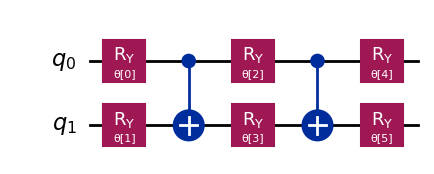

In [9]:
def build_ansatz(num_qubits=2, num_layers=2):
    """
    Ansatz hardware-efficient: camada inicial de RY + L repetições de (CNOT + RY).
    Total de parâmetros: num_qubits * (num_layers + 1).
    """
    num_params = num_qubits * (num_layers + 1)
    params = ParameterVector('θ', length=num_params)
    qc = QuantumCircuit(num_qubits)
    param_idx = 0

    # Camada inicial de rotações RY
    for q in range(num_qubits):
        qc.ry(params[param_idx], q)
        param_idx += 1

    # L camadas de emaranhamento + rotação
    for _ in range(num_layers):
        # Emaranhamento: CNOT em cadeia
        for q in range(num_qubits - 1):
            qc.cx(q, q + 1)
        # Rotações após emaranhamento
        for q in range(num_qubits):
            qc.ry(params[param_idx], q)
            param_idx += 1

    return qc, params

ansatz, params = build_ansatz(num_qubits=2, num_layers=2)
print(f"Ansatz: {len(params)} parâmetros, profundidade {ansatz.depth()}")
ansatz.draw('mpl')

## A função de custo e o loop VQE

A função de custo é:

$$\mathcal{L}(\theta) = \langle\psi(\theta)|H|\psi(\theta)\rangle = \sum_k c_k \langle\psi(\theta)| P_{k,1}\otimes\cdots\otimes P_{k,n} |\psi(\theta)\rangle$$

Cada chamada dessa função exige a execução do circuito no hardware (ou simulador) para obter os valores esperados de cada termo de Pauli. O otimizador clássico trata essa função como uma caixa preta: ele não tem acesso à estrutura interna do circuito, apenas ao valor retornado.

O Estimator do Qiskit recebe pares (circuito, observável) chamados de *PUBs* (*Primitive Unified Blocs*) no Qiskit 2.x. Para um par, a chamada é:

```python
job = estimator.run([(circuito, hamiltonian)])
resultado = job.result()
valor_esperado = resultado[0].data.evs
```

O campo `.evs` contém o valor esperado calculado. Para o `StatevectorEstimator` (simulação exata), esse valor é determinístico. Para backends com shots finitos ou ruído, ele é uma estimativa estocástica.

O método de otimização que usaremos é o **COBYLA** (*Constrained Optimization BY Linear Approximations*). Ele é um otimizador livre de gradiente, não requer derivadas da função de custo, apenas avaliações do próprio valor. Isso o torna robusto para funções ruidosas, mas mais lento para convergir do que métodos baseados em gradiente. Para problemas pequenos com poucos parâmetros, é uma boa escolha inicial.

In [10]:
estimator_ideal = StatevectorEstimator()
energy_history = []

def cost_function(param_values):
    """
    Avalia L(θ) = <ψ(θ)|H|ψ(θ)>.
    assign_parameters() substitui os ParameterVector pelos valores concretos.
    """
    bound_circuit = ansatz.assign_parameters(param_values)
    job = estimator_ideal.run([(bound_circuit, hamiltonian)])
    energy = job.result()[0].data.evs.item()
    energy_history.append(energy)
    return energy

# Ponto inicial: parâmetros aleatórios em [-π, π]
np.random.seed(42)
theta_init = np.random.uniform(-np.pi, np.pi, len(params))

E_init = cost_function(theta_init)
print(f"Energia inicial L(θ_0) = {E_init:.6f}")
print(f"Energia exata       E0 = {E0_exact:.6f}")
print(f"Gap inicial:           {E_init - E0_exact:.6f}")

Energia inicial L(θ_0) = 0.066261
Energia exata       E0 = -0.804584
Gap inicial:           0.870845


In [11]:
energy_history = []  # reinicia antes de otimizar

result_vqe = minimize(
    cost_function,
    theta_init,
    method='COBYLA',
    options={'maxiter': 500, 'rhobeg': 0.5}  # rhobeg: tamanho inicial do passo
)

E_vqe   = result_vqe.fun
theta_opt = result_vqe.x

print(f"Iterações: {result_vqe.nfev} avaliações de função")
print(f"Energia VQE:   {E_vqe:.6f}")
print(f"Energia exata: {E0_exact:.6f}")
print(f"Erro absoluto: {abs(E_vqe - E0_exact):.2e}")

Iterações: 116 avaliações de função
Energia VQE:   -0.804584
Energia exata: -0.804584
Erro absoluto: 1.85e-10


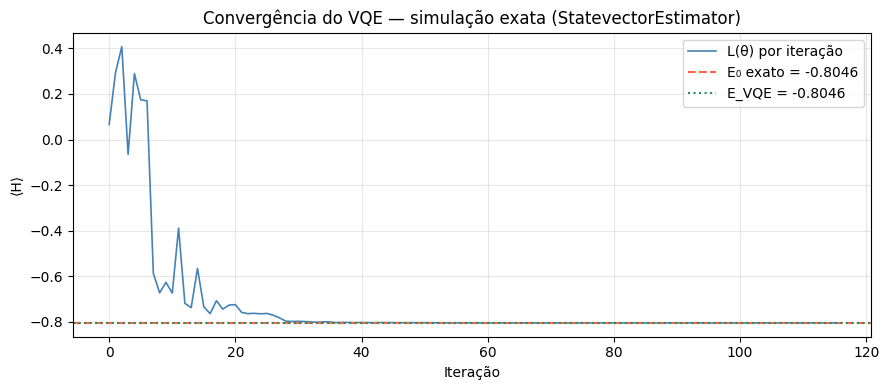

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(energy_history, color='steelblue', lw=1.2, label='L(θ) por iteração')
ax.axhline(E0_exact, color='tomato', ls='--', lw=1.5, label=f'E₀ exato = {E0_exact:.4f}')
ax.axhline(E_vqe,    color='seagreen', ls=':',  lw=1.5, label=f'E_VQE = {E_vqe:.4f}')
ax.set_xlabel('Iteração'); ax.set_ylabel('⟨H⟩'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Convergência do VQE — simulação exata (StatevectorEstimator)')
plt.tight_layout(); plt.show()

## Analisando o estado ótimo

O VQE retorna não apenas a energia, mas o vetor $\theta^*$ que define o estado ótimo $|\psi(\theta^*)\rangle$. Vale a pena inspecionar esse estado para entender o que o algoritmo encontrou.

Uma medida natural de qualidade é a **fidelidade** entre o estado encontrado $|\psi(\theta^*)\rangle$ e o autoestado exato $|e_0\rangle$:

$$F = |\langle e_0 | \psi(\theta^*) \rangle|^2$$

A fidelidade vale 1 quando os estados são idênticos (a menos de fase global) e 0 quando são ortogonais. Em simulação ideal, esperamos $F \approx 1$ se o ansatz for suficientemente expressivo para representar o estado fundamental.

Note que a fidelidade é invariante por fase global: se $|e_0\rangle = e^{i\phi}|\psi(\theta^*)\rangle$ para alguma fase $\phi$, temos $F = 1$. Por isso usamos o módulo ao quadrado.

In [13]:
# Estado encontrado pelo VQE
sv_vqe   = Statevector(ansatz.assign_parameters(theta_opt))
# Autoestado exato (primeira coluna de eigenvectors após eigh)
sv_exact = Statevector(eigenvectors[:, 0])

print("Estado VQE |ψ(θ*)⟩ nas bases computacionais:")
for state, amp in sv_vqe.to_dict().items():
    print(f"  |{state}⟩: amplitude = {amp:.4f}, prob = {abs(amp)**2:.4f}")

print("\nAutoestado exato |e₀⟩:")
for state, amp in sv_exact.to_dict().items():
    print(f"  |{state}⟩: amplitude = {amp:.4f}, prob = {abs(amp)**2:.4f}")

fidelidade = abs(sv_exact.inner(sv_vqe))**2
print(f"\nFidelidade F = |⟨e₀|ψ(θ*)⟩|² = {fidelidade:.8f}")

Estado VQE |ψ(θ*)⟩ nas bases computacionais:
  |00⟩: amplitude = 0.4142+0.0000j, prob = 0.1716
  |01⟩: amplitude = -0.6245+0.0000j, prob = 0.3901
  |10⟩: amplitude = -0.6245+0.0000j, prob = 0.3900
  |11⟩: amplitude = 0.2198+0.0000j, prob = 0.0483

Autoestado exato |e₀⟩:
  |00⟩: amplitude = -0.4142+0.0000j, prob = 0.1716
  |01⟩: amplitude = 0.6245+0.0000j, prob = 0.3900
  |10⟩: amplitude = 0.6245+0.0000j, prob = 0.3900
  |11⟩: amplitude = -0.2198+0.0000j, prob = 0.0483

Fidelidade F = |⟨e₀|ψ(θ*)⟩|² = 1.00000000


## A regra do deslocamento de parâmetro

Para otimizar eficientemente, especialmente em hardware real, é fundamental calcular o **gradiente** da função de custo em relação a cada parâmetro. A questão é: como calcular $\partial\mathcal{L}/\partial\theta_k$ se $\mathcal{L}$ é obtido por medições quânticas?

A resposta é a **parameter-shift rule**, uma identidade exata (não uma aproximação) válida para portas da forma:

$$U(\theta_k) = e^{-i\theta_k G/2}$$

onde $G$ é um operador hermitiano com autovalores em $\{-1/2, +1/2\}$ (como as matrizes de Pauli normalizadas). Nesse caso:

$$\frac{\partial}{\partial\theta_k}\langle\psi(\theta)|H|\psi(\theta)\rangle = \frac{1}{2}\left[\mathcal{L}\left(\theta_k + \frac{\pi}{2}\right) - \mathcal{L}\left(\theta_k - \frac{\pi}{2}\right)\right]$$

A demonstração usa a estrutura espectral de $G$. Como $G$ tem apenas dois autovalores distintos ($\pm 1/2$), a função $\mathcal{L}(\theta_k)$ é uma senoide perfeita em $\theta_k$: $\mathcal{L}(\theta_k) = A \cos(\theta_k + \phi) + C$. A derivada dessa senoide pode ser calculada pela diferença em pontos a $\pm\pi/2$ de distância, o que explica a fórmula acima.

Para $R_Y(\theta) = e^{-i\theta Y/2}$, o gerador é $G = Y/2$ com autovalores $\pm 1/2$, então a regra se aplica diretamente.

O gradiente completo requer $2n$ execuções de circuito (duas por parâmetro). Isso é muito mais eficiente que diferenças finitas com passo $\epsilon$, que além de requerer $2n$ execuções introduz erro de discretização da ordem de $O(\epsilon^2)$. A parameter-shift rule é exata.

In [14]:
def energy_at(param_values):
    bound = ansatz.assign_parameters(param_values)
    job   = estimator_ideal.run([(bound, hamiltonian)])
    return job.result()[0].data.evs.item()

def gradient_parameter_shift(theta):
    """
    Gradiente exato via parameter-shift rule.
    Custo: 2 * len(theta) execuções de circuito.
    """
    grad = np.zeros_like(theta)
    for k in range(len(theta)):
        t_plus  = theta.copy(); t_plus[k]  += np.pi/2
        t_minus = theta.copy(); t_minus[k] -= np.pi/2
        grad[k] = 0.5 * (energy_at(t_plus) - energy_at(t_minus))
    return grad

def gradient_finite_diff(theta, eps=1e-5):
    """
    Gradiente por diferenças finitas centrais.
    Erro de ordem O(eps^2), mas simples de implementar.
    """
    grad = np.zeros_like(theta)
    for k in range(len(theta)):
        t_plus  = theta.copy(); t_plus[k]  += eps
        t_minus = theta.copy(); t_minus[k] -= eps
        grad[k] = (energy_at(t_plus) - energy_at(t_minus)) / (2 * eps)
    return grad

# Ponto de teste
theta_test = np.array([0.3, -0.5, 1.2, 0.8, -1.1, 0.4])

grad_ps = gradient_parameter_shift(theta_test)
grad_fd = gradient_finite_diff(theta_test)

print("Parameter-shift vs Diferenças finitas:")
print(f"{'k':>3}  {'Param-shift':>15}  {'Dif. finitas':>15}  {'|erro|':>12}")
print("-" * 50)
for k in range(len(theta_test)):
    print(f"{k:>3}  {grad_ps[k]:>15.8f}  {grad_fd[k]:>15.8f}  {abs(grad_ps[k]-grad_fd[k]):>12.2e}")

Parameter-shift vs Diferenças finitas:
  k      Param-shift     Dif. finitas        |erro|
--------------------------------------------------
  0       0.19955789       0.19955789      3.80e-12
  1       0.33684999       0.33684999      6.67e-12
  2       0.30682386       0.30682386      2.20e-12
  3       0.18626685       0.18626685      4.09e-12
  4       0.52475875       0.52475875      6.70e-12
  5      -0.24610794      -0.24610794      4.13e-12


## VQE com descida de gradiente usando parameter-shift

Com gradientes analíticos disponíveis, podemos implementar descida de gradiente diretamente, sem delegar ao otimizador do scipy. A atualização na iteração $t$ é:

$$\theta^{(t+1)} = \theta^{(t)} - \eta \, \nabla_\theta \mathcal{L}(\theta^{(t)})$$

onde $\eta > 0$ é a taxa de aprendizado (*learning rate*). Essa é a forma mais simples; na prática, métodos como Adam (que mantém médias móveis dos gradientes) convergem mais rápido.

Vamos comparar COBYLA (livre de gradiente) com descida de gradiente via parameter-shift na mesma tarefa:

Energia final (descida de gradiente): -0.804584
Energia exata:                        -0.804584


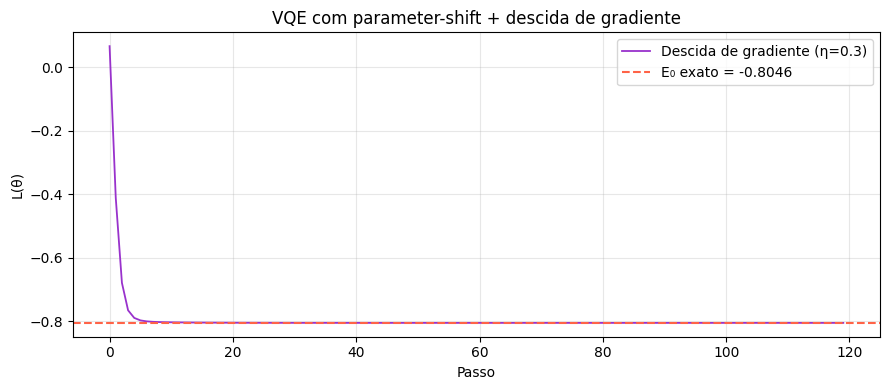

In [15]:
np.random.seed(42)
theta = np.random.uniform(-np.pi, np.pi, len(params))
eta = 0.3          # taxa de aprendizado
n_steps = 120

gd_history = []

for step in range(n_steps):
    e = energy_at(theta)
    gd_history.append(e)
    grad = gradient_parameter_shift(theta)
    theta = theta - eta * grad

E_gd = energy_at(theta)
print(f"Energia final (descida de gradiente): {E_gd:.6f}")
print(f"Energia exata:                        {E0_exact:.6f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(gd_history, color='darkorchid', lw=1.3, label='Descida de gradiente (η=0.3)')
ax.axhline(E0_exact, color='tomato', ls='--', lw=1.5, label=f'E₀ exato = {E0_exact:.4f}')
ax.set_xlabel('Passo'); ax.set_ylabel('L(θ)'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('VQE com parameter-shift + descida de gradiente')
plt.tight_layout(); plt.show()

## VQE com ruído: efeito do canal de depolarização

Em hardware real, cada porta introduz erros. O modelo mais simples é o **canal de depolarização**, que com probabilidade $p$ substitui o estado do qubit por um estado completamente misturado:

$$\mathcal{E}_p(\rho) = (1-p)\rho + \frac{p}{3}\left(X\rho X + Y\rho Y + Z\rho Z\right)$$

Em termos do vetor de Bloch $\vec{r}$ (com $\rho = (I + \vec{r}\cdot\vec{\sigma})/2$), o canal de depolarização contrai o vetor:

$$\vec{r} \mapsto \left(1 - \frac{4p}{3}\right)\vec{r}$$

Para $p = 3/4$, o estado é mapeado na identidade (máxima mistura). O canal age igualmente em todas as direções é isotrópico.

No contexto do VQE, o ruído tem dois efeitos: (1) ele "aquece" o estado para a mistura máxima, deslocando o valor esperado em direção a $\text{tr}(H)/2^n$; e (2) ele introduz variância estatística nas medições. Primeiro o VQE converge para uma energia mais alta que $E_0$, e o depois torna a superfície de custo mais ruidosa e dificulta a otimização.

Para portas de dois qubits (como o CNOT), as taxas de erro são tipicamente uma ordem de magnitude maiores do que para portas de um qubit. Modelamos isso explicitamente abaixo.

In [25]:
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as AerEstimator  # garante V2

def run_vqe_noisy(noise_p, seed=42):
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(depolarizing_error(noise_p,       1), ['ry'])
    nm.add_all_qubit_quantum_error(depolarizing_error(10 * noise_p,  2), ['cx'])

    # Cria o backend com o noise model e passa como 'backend'
    backend   = AerSimulator(noise_model=nm)
    estimator = AerEstimator(backend=backend)

    hist = []

    def cost(tv):
        bound = ansatz.assign_parameters(tv)
        job   = estimator.run([(bound, hamiltonian)])
        val   = float(np.real(job.result()[0].data.evs))
        hist.append(val)
        return val

    np.random.seed(seed)
    x0  = np.random.uniform(-np.pi, np.pi, len(params))
    res = minimize(cost, x0, method='COBYLA', options={'maxiter': 400, 'rhobeg': 0.5})
    return res.fun, hist

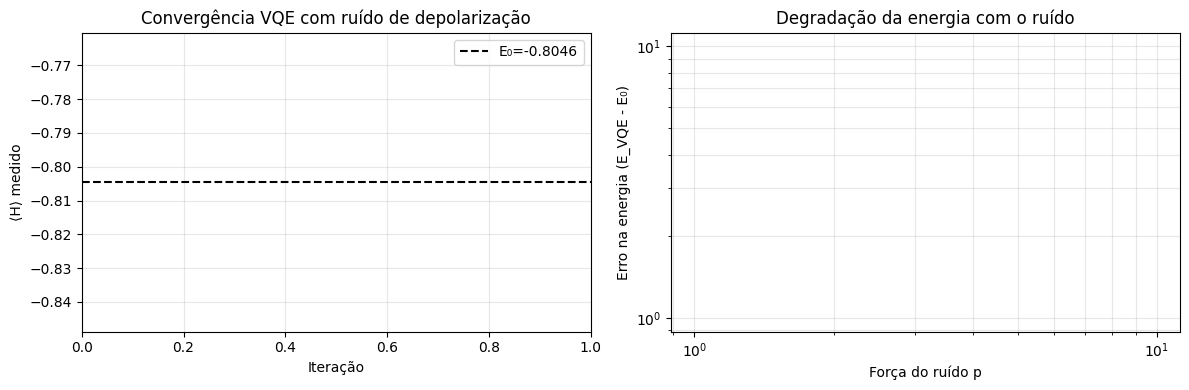

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cores = ['steelblue', 'darkorange', 'tomato']
for (p, (e_min, hist)), cor in zip(noisy_results.items(), cores):
    axes[0].plot(hist, color=cor, alpha=0.75, lw=1.0, label=f'p={p:.3f} → E={e_min:.3f}')
axes[0].axhline(E0_exact, color='black', ls='--', lw=1.5, label=f'E₀={E0_exact:.4f}')
axes[0].set_xlabel('Iteração'); axes[0].set_ylabel('⟨H⟩ medido')
axes[0].set_title('Convergência VQE com ruído de depolarização')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Erro em função da força do ruído
ps   = list(noisy_results.keys())
errs = [noisy_results[p][0] - E0_exact for p in ps]
axes[1].loglog(ps, errs, 'o-', color='steelblue', lw=1.5)
axes[1].set_xlabel('Força do ruído p'); axes[1].set_ylabel('Erro na energia (E_VQE - E₀)')
axes[1].set_title('Degradação da energia com o ruído'); axes[1].grid(alpha=0.3, which='both')

plt.tight_layout(); plt.show()

## QAOA: algoritmo variacional para otimização combinatória

O **QAOA** (*Quantum Approximate Optimization Algorithm*, Farhi et al. 2014) aplica o paradigma variacional a problemas de otimização combinatória. Em vez de um ansatz genérico, o QAOA usa uma estrutura motivada pela **evolução adiabática quântica**.

A ideia do adiabatismo é: começamos com o estado fundamental $|+\rangle^{\otimes n}$ de um hamiltoniano simples $H_B$ (o "mixer"), e lentamente interpolamos para o hamiltoniano do problema $H_C$. Se a interpolação for lenta o suficiente, o teorema adiabático garante que o sistema permanece no estado fundamental (solução do problema).

O QAOA *discretiza* essa evolução em $p$ passos, alternando entre os dois operadores unitários:

$$|\gamma, \beta\rangle = \underbrace{e^{-i\beta_p H_B}}_{U_B(\beta_p)} \underbrace{e^{-i\gamma_p H_C}}_{U_C(\gamma_p)} \cdots \underbrace{e^{-i\beta_1 H_B}}_{U_B(\beta_1)} \underbrace{e^{-i\gamma_1 H_C}}_{U_C(\gamma_1)} |+\rangle^{\otimes n}$$

Os parâmetros $\gamma = (\gamma_1, \ldots, \gamma_p)$ e $\beta = (\beta_1, \ldots, \beta_p)$ são otimizados para maximizar o valor esperado de $H_C$, que é a função objetivo.

O hamiltoniano mixer é simplesmente $H_B = \sum_j X_j$, cuja evolução é uma rotação $R_X$ em cada qubit:

$$U_B(\beta) = e^{-i\beta \sum_j X_j} = \prod_j e^{-i\beta X_j} = \prod_j R_X(2\beta)_j$$

Para o **problema MaxCut**, dado um grafo $G = (V, E)$, o hamiltoniano é:

$$H_C = \sum_{(i,j) \in E} \frac{1 - Z_i Z_j}{2}$$

O valor esperado de $H_C$ no estado $|\gamma,\beta\rangle$ dá o número esperado de arestas cortadas pela bipartição definida pelo estado. Maximizar isso é o objetivo do MaxCut.

A implementação do operador de problema $U_C(\gamma)$ para cada aresta $(i,j)$ usa a identidade:

$$e^{-i\gamma (1 - Z_i Z_j)/2} = e^{-i\gamma/2} \cdot e^{i\gamma Z_i Z_j/2}$$

O fator de fase global $e^{-i\gamma/2}$ pode ser ignorado. O operador $e^{i\gamma Z_i Z_j/2}$ é implementado com o circuito `CNOT → Rz(2γ) → CNOT`, que é o circuito padrão para exponenciais de operadores $ZZ$.

Circuito QAOA (p=2): 4 parâmetros, profundidade 33

Hamiltoniano MaxCut:
SparsePauliOp(['IIZZ', 'IZZI', 'ZZII', 'ZIIZ', 'IZIZ'],
              coeffs=[-0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j])


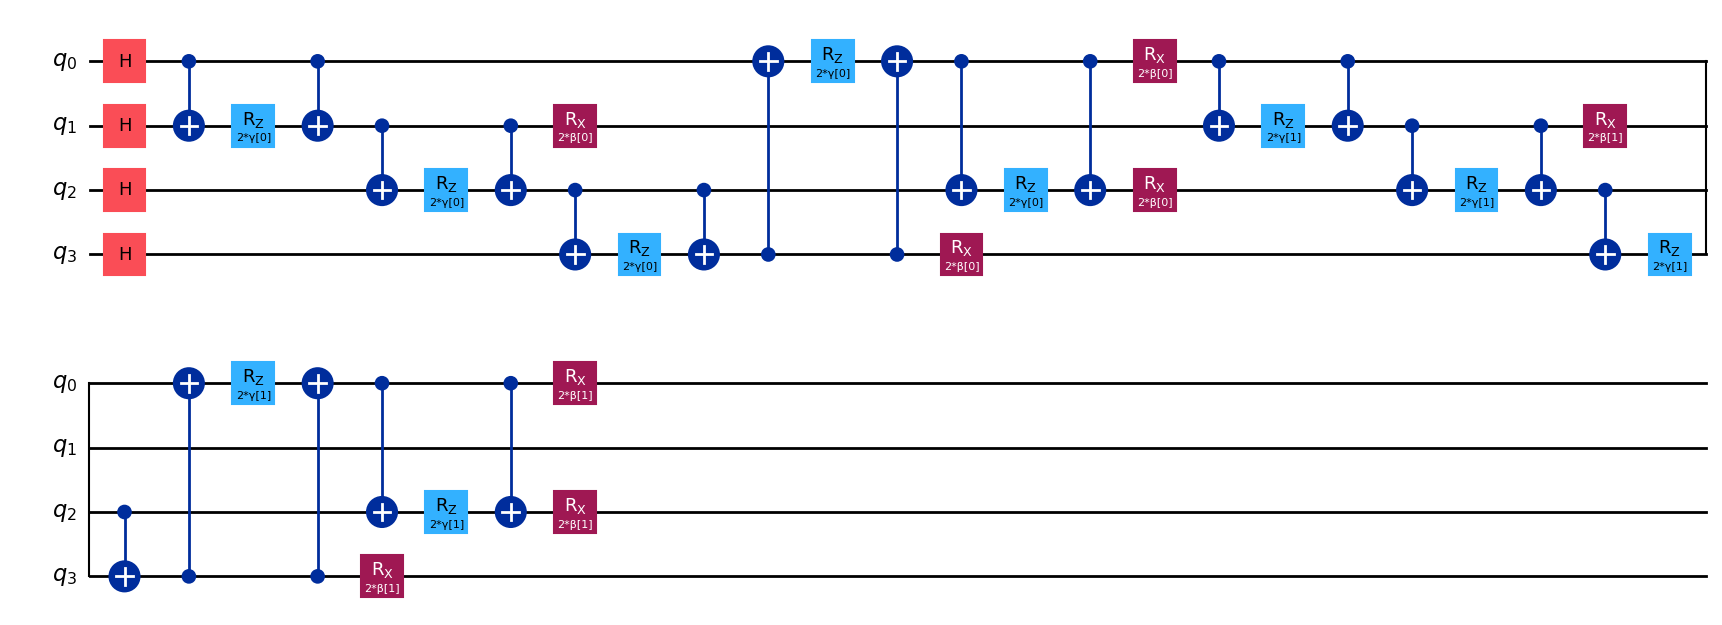

In [17]:
# Grafo: 4 vértices, 5 arestas (quadrado + diagonal)
edges      = [(0, 1), (1, 2), (2, 3), (3, 0), (0, 2)]
n_vertices = 4

def maxcut_hamiltonian(edges, n):
    """
    H_C = sum_{(i,j) in E} (I - Z_i Z_j) / 2
    Minimizamos -H_C, então os coeficientes de Z_i Z_j ficam positivos.
    """
    terms = []
    for (i, j) in edges:
        s = ['I'] * n
        s[i] = 'Z'; s[j] = 'Z'
        # Qiskit: índice 0 = rightmost char
        terms.append((''.join(reversed(s)), -0.5))
    return SparsePauliOp.from_list(terms)

def qaoa_circuit(edges, n, p=1):
    """
    Circuito QAOA com p camadas.
    Parâmetros: γ = (γ₁,...,γₚ) para U_C e β = (β₁,...,βₚ) para U_B.
    """
    gamma = ParameterVector('γ', p)
    beta  = ParameterVector('β', p)
    qc    = QuantumCircuit(n)

    # Estado inicial: superposição uniforme |+>^n
    qc.h(range(n))

    for layer in range(p):
        # U_C(γ): e^{i γ Z_i Z_j / 2} para cada aresta
        # Implementação: CNOT → Rz(2γ) → CNOT
        for (i, j) in edges:
            qc.cx(i, j)
            qc.rz(2 * gamma[layer], j)
            qc.cx(i, j)

        # U_B(β): Rx(2β) em cada qubit
        for q in range(n):
            qc.rx(2 * beta[layer], q)

    return qc, gamma, beta

H_cut = maxcut_hamiltonian(edges, n_vertices)
qc_qaoa, gamma_p, beta_p = qaoa_circuit(edges, n_vertices, p=2)

print(f"Circuito QAOA (p=2): {qc_qaoa.num_parameters} parâmetros, profundidade {qc_qaoa.depth()}")

print("\nHamiltoniano MaxCut:")
print(H_cut)
qc_qaoa.draw('mpl')

In [18]:
qaoa_hist = []
all_params = list(gamma_p) + list(beta_p)  # 4 parâmetros para p=2

def qaoa_cost(pv):
    bound = qc_qaoa.assign_parameters(pv)
    job   = estimator_ideal.run([(bound, H_cut)])
    val   = job.result()[0].data.evs.item()
    qaoa_hist.append(val)
    return val  # H_cut tem sinal negativo => minimizar = maximizar corte

np.random.seed(7)
x0 = np.random.uniform(0, np.pi, len(all_params))
res_qaoa = minimize(qaoa_cost, x0, method='COBYLA', options={'maxiter': 600, 'rhobeg': 0.3})

print(f"Parâmetros ótimos: γ = {np.round(res_qaoa.x[:2], 4)},  β = {np.round(res_qaoa.x[2:], 4)}")
print(f"Corte esperado (valor de -H_cut): {-res_qaoa.fun:.4f} arestas")

Parâmetros ótimos: γ = [0.4721 2.0598],  β = [1.447  2.0479]
Corte esperado (valor de -H_cut): 1.7387 arestas


In [19]:
# Decodificando a solução: medimos o estado ótimo e olhamos a distribuição
optimal_qc = qc_qaoa.assign_parameters(res_qaoa.x)
optimal_qc_m = optimal_qc.copy()
optimal_qc_m.measure_all()

sampler = StatevectorSampler()
job_s   = sampler.run([(optimal_qc_m,)], shots=4096)
counts  = job_s.result()[0].data.meas.get_counts()

def cut_value(bs, edges):
    """Número de arestas cortadas pela bipartição definida pela string de bits."""
    return sum(1 for (i,j) in edges if bs[i] != bs[j])

# Verificação por força bruta
best_cut = max(cut_value(list(cfg), edges) for cfg in product('01', repeat=n_vertices))

print("Distribuição de resultados (top 8):")
print(f"{'Configuração':>14}  {'Contagens':>9}  {'Corte':>7}  {'Ótimo?':>7}")
print("-" * 44)
for bs, count in sorted(counts.items(), key=lambda x: -x[1])[:8]:
    cfg = list(bs[::-1])  # qiskit: qubit 0 é o rightmost
    c   = cut_value(cfg, edges)
    print(f"  {bs:>12}  {count:>9}  {c:>7}  {'sim' if c == best_cut else '':>7}")

print(f"\nCorte máximo (força bruta): {best_cut} arestas")

# Probabilidade de amostrar uma solução ótima
p_opt = sum(v for k, v in counts.items() if cut_value(list(k[::-1]), edges) == best_cut) / 4096
print(f"Probabilidade de amostrar configuração ótima: {p_opt:.2%}")

Distribuição de resultados (top 8):
  Configuração  Contagens    Corte   Ótimo?
--------------------------------------------
          1111       1466        0         
          0000       1397        0         
          0111        174        2         
          1000        172        2         
          0010        146        2         
          1100        143        3         
          1001        139        3         
          1101        138        2         

Corte máximo (força bruta): 4 arestas
Probabilidade de amostrar configuração ótima: 0.10%


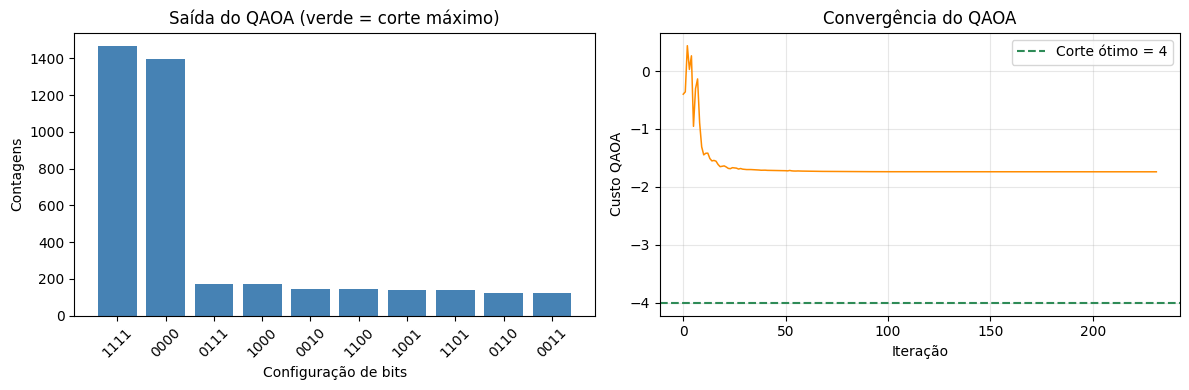

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

top = sorted(counts.items(), key=lambda x: -x[1])[:10]
labels_q = [t[0] for t in top]
vals_q   = [t[1] for t in top]
cuts_q   = [cut_value(list(l[::-1]), edges) for l in labels_q]
colors_q = ['seagreen' if c == best_cut else 'steelblue' for c in cuts_q]

axes[0].bar(labels_q, vals_q, color=colors_q)
axes[0].set_xlabel('Configuração de bits'); axes[0].set_ylabel('Contagens')
axes[0].set_title('Saída do QAOA (verde = corte máximo)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(qaoa_hist, color='darkorange', lw=1.1)
axes[1].axhline(-best_cut, color='seagreen', ls='--', lw=1.5, label=f'Corte ótimo = {best_cut}')
axes[1].set_xlabel('Iteração'); axes[1].set_ylabel('Custo QAOA')
axes[1].set_title('Convergência do QAOA'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## Barren plateaus: o obstáculo fundamental da escalabilidade

Existe um problema sério com ansatze variacionais genéricos quando o número de qubits cresce. Em 2018, McClean et al. demonstraram que, sob certas condições, os gradientes da função de custo se tornam exponencialmente pequenos com $n$, fenômeno chamado de **barren plateau** ("platô estéril").

O resultado central é: para um ansatz formado por circuitos aleatórios suficientemente profundos (que formam o que se chama de *2-design* sobre o grupo unitário), o gradiente em relação a qualquer parâmetro $\theta_k$ satisfaz:

$$\mathbb{E}\left[\frac{\partial \mathcal{L}}{\partial \theta_k}\right] = 0$$

$$\text{Var}\left[\frac{\partial \mathcal{L}}{\partial \theta_k}\right] \leq \frac{\text{const}}{2^n}$$

onde a média e a variância são tomadas sobre parâmetros aleatórios uniformemente distribuídos. Em palavras: o gradiente tem média zero e variância que decai exponencialmente com $n$. Isso significa que, com alta probabilidade, qualquer ponto no espaço de parâmetros parece um mínimo — todos os gradientes são exponencialmente pequenos, e é impossível determinar uma direção de descida.

A intuição geométrica é que ansatze expressivos cobrem o espaço de estados de forma tão uniforme que a superfície de custo se torna quase plana na média. Para distinguir o gradiente real do ruído de medição, precisaríamos de um número exponencial de shots.

O barren plateau é uma das principais razões pelas quais a escalabilidade de VQAs genéricos para muitos qubits é questionada. Soluções ativas de pesquisa incluem:

- Usar ansatze com estrutura específica do problema (como QAOA), que não sofrem desse problema na mesma extensão.
- Inicialização cuidadosa dos parâmetros (perto de zero, o que localiza o circuito).
- Treinar em patches menores do circuito e depois combinar.
- Usar funções de custo locais (com observáveis que atuam em poucos qubits), que apresentam gradientes mais bem comportados.

Vamos verificar o fenômeno experimentalmente, calculando a variância do gradiente para ansatze de diferentes tamanhos.

In [21]:
def gradient_variance(n_qubits, n_samples=60):
    """
    Estima Var[∂L/∂θ₀] para um ansatz de n_qubits qubits.
    Usa n_layers = n_qubits para garantir expressividade crescente.
    """
    circ, par = build_ansatz(num_qubits=n_qubits, num_layers=n_qubits)

    # Hamiltoniano: soma de Z em todos os qubits (local, simples)
    terms_H = [('I' * (n_qubits - 1 - q) + 'Z' + 'I' * q, 1.0) for q in range(n_qubits)]
    H_local = SparsePauliOp.from_list(terms_H)

    grads = []
    for _ in range(n_samples):
        theta = np.random.uniform(-np.pi, np.pi, len(par))

        # Parameter-shift no parâmetro 0
        tp = theta.copy(); tp[0] += np.pi/2
        tm = theta.copy(); tm[0] -= np.pi/2

        job = estimator_ideal.run([
            (circ.assign_parameters(tp), H_local),
            (circ.assign_parameters(tm), H_local)
        ])
        res = job.result()
        g = 0.5 * (res[0].data.evs.item() - res[1].data.evs.item())
        grads.append(g)

    return np.var(grads)

qubit_ns = [2, 3, 4, 5, 6]
variances = []
print("Calculando variâncias do gradiente para diferentes tamanhos de sistema...")
for n in qubit_ns:
    v = gradient_variance(n, n_samples=50)
    variances.append(v)
    print(f"  n = {n}: Var[∂L/∂θ₀] = {v:.3e}")

# Ajuste exponencial: Var ~ A * exp(b * n)
log_v  = np.log(variances)
coeffs = np.polyfit(qubit_ns, log_v, 1)
print(f"\nAjuste: Var ~ exp({coeffs[0]:.3f} * n)")
print(f"Fator por qubit adicionado: {np.exp(coeffs[0]):.3f}  (teórico: 0.5)")

Calculando variâncias do gradiente para diferentes tamanhos de sistema...
  n = 2: Var[∂L/∂θ₀] = 5.040e-01
  n = 3: Var[∂L/∂θ₀] = 3.167e-01
  n = 4: Var[∂L/∂θ₀] = 2.649e-01
  n = 5: Var[∂L/∂θ₀] = 2.024e-01
  n = 6: Var[∂L/∂θ₀] = 1.380e-01

Ajuste: Var ~ exp(-0.304 * n)
Fator por qubit adicionado: 0.738  (teórico: 0.5)


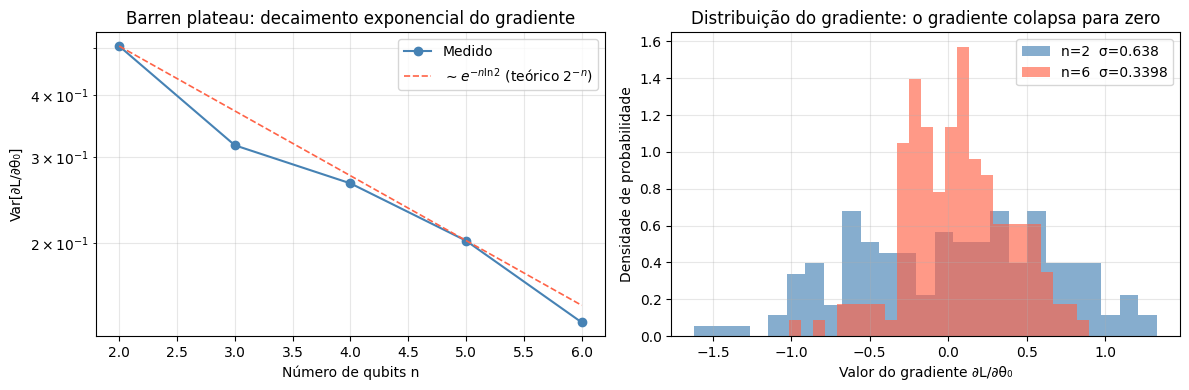

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Variância vs n (escala log)
n_fine   = np.linspace(2, 6, 100)
var_theo = variances[0] * np.exp(coeffs[0] * (n_fine - qubit_ns[0]))
axes[0].semilogy(qubit_ns, variances, 'o-', color='steelblue', lw=1.5, ms=6, label='Medido')
axes[0].semilogy(n_fine, var_theo, '--', color='tomato', lw=1.2, label=r'$\sim e^{-n \ln 2}$ (teórico $2^{-n}$)')
axes[0].set_xlabel('Número de qubits n')
axes[0].set_ylabel('Var[∂L/∂θ₀]')
axes[0].set_title('Barren plateau: decaimento exponencial do gradiente')
axes[0].legend(); axes[0].grid(alpha=0.3, which='both')

# Distribuição dos gradientes: n=2 vs n=6
def sample_grads(n, n_samp=200):
    circ, par = build_ansatz(num_qubits=n, num_layers=n)
    terms_H = [('I' * (n - 1 - q) + 'Z' + 'I' * q, 1.0) for q in range(n)]
    H_local = SparsePauliOp.from_list(terms_H)
    grads = []
    for _ in range(n_samp):
        theta = np.random.uniform(-np.pi, np.pi, len(par))
        tp = theta.copy(); tp[0] += np.pi/2
        tm = theta.copy(); tm[0] -= np.pi/2
        job = estimator_ideal.run([
            (circ.assign_parameters(tp), H_local),
            (circ.assign_parameters(tm), H_local)
        ])
        res = job.result()
        grads.append(0.5 * (res[0].data.evs.item() - res[1].data.evs.item()))
    return grads

g2 = sample_grads(2, 150)
g6 = sample_grads(6, 150)

axes[1].hist(g2, bins=25, alpha=0.65, color='steelblue', density=True, label=f'n=2  σ={np.std(g2):.3f}')
axes[1].hist(g6, bins=25, alpha=0.65, color='tomato',    density=True, label=f'n=6  σ={np.std(g6):.4f}')
axes[1].set_xlabel('Valor do gradiente ∂L/∂θ₀')
axes[1].set_ylabel('Densidade de probabilidade')
axes[1].set_title('Distribuição do gradiente: o gradiente colapsa para zero')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## Expressibilidade do ansatz

A **expressibilidade** de um ansatz mede o quanto ele consegue cobrir o espaço de estados quânticos ao variar seus parâmetros. Um ansatz com expressibilidade máxima seria capaz de gerar qualquer estado no espaço de Hilbert — ele se comportaria como um elemento aleatório do grupo unitário $U(2^n)$ com distribuição de Haar.

Uma forma quantitativa de medir expressibilidade é comparar a distribuição de fidelidades $F = |\langle\psi(\theta_1)|\psi(\theta_2)\rangle|^2$ entre pares de estados gerados com parâmetros aleatórios, com a distribuição esperada para estados Haar-aleatórios.

Para um espaço de dimensão $D = 2^n$, a densidade de probabilidade da fidelidade entre dois estados Haar-aleatórios é:

$$P_{\text{Haar}}(F) = (D-1)(1-F)^{D-2}, \qquad F \in [0,1]$$

Essa é uma distribuição Beta com parâmetros $(1, D-1)$, concentrada próxima de $F = 0$ para grandes $D$ (o que reflete o fato de que dois vetores aleatórios em alta dimensão são quase sempre quase ortogonais).

Quanto mais próxima a distribuição do ansatz da curva de Haar, mais expressivo ele é. Existe porém o compromisso já mencionado: expressibilidade alta implica gradientes pequenos (barren plateaus). O design de um bom ansatz consiste em navegar esse compromisso, muitas vezes incorporando conhecimento do problema.

Calculando distribuições de fidelidade...


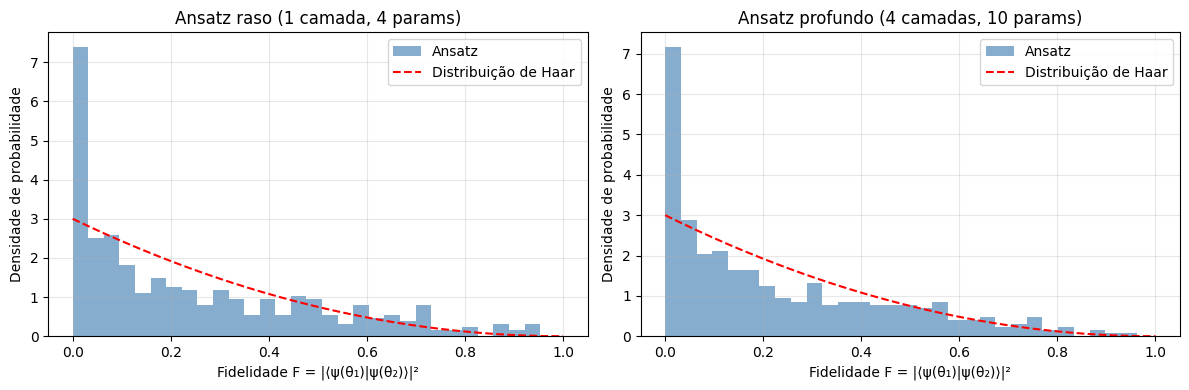

Quanto mais próxima a curva azul da curva vermelha (Haar), maior a expressibilidade.


In [23]:
def fidelity_distribution(circ, par, n_samp=400):
    fids = []
    for _ in range(n_samp):
        t1 = np.random.uniform(-np.pi, np.pi, len(par))
        t2 = np.random.uniform(-np.pi, np.pi, len(par))
        sv1 = Statevector(circ.assign_parameters(t1))
        sv2 = Statevector(circ.assign_parameters(t2))
        fids.append(abs(sv1.inner(sv2))**2)
    return np.array(fids)

n_q = 2
circ_shallow, par_shallow = build_ansatz(n_q, num_layers=1)
circ_deep,    par_deep    = build_ansatz(n_q, num_layers=4)

print("Calculando distribuições de fidelidade...")
fids_shallow = fidelity_distribution(circ_shallow, par_shallow, n_samp=400)
fids_deep    = fidelity_distribution(circ_deep,    par_deep,    n_samp=400)

D = 2**n_q
F_range  = np.linspace(0, 1, 300)
haar_pdf = (D - 1) * (1 - F_range)**(D - 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, fids, title in zip(
    axes,
    [fids_shallow, fids_deep],
    [f'Ansatz raso (1 camada, {len(par_shallow)} params)', f'Ansatz profundo (4 camadas, {len(par_deep)} params)']
):
    ax.hist(fids, bins=30, density=True, alpha=0.65, color='steelblue', label='Ansatz')
    ax.plot(F_range, haar_pdf, 'r--', lw=1.5, label='Distribuição de Haar')
    ax.set_xlabel('Fidelidade F = |⟨ψ(θ₁)|ψ(θ₂)⟩|²')
    ax.set_ylabel('Densidade de probabilidade')
    ax.set_title(title)
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()
print("Quanto mais próxima a curva azul da curva vermelha (Haar), maior a expressibilidade.")

## Visualizando a superfície de custo

Para desenvolver intuição sobre o comportamento do otimizador, é útil visualizar a superfície de custo $\mathcal{L}(\theta)$ em uma fatia bidimensional do espaço de parâmetros, fixamos todos os parâmetros nos valores ótimos e variamos apenas dois deles.

Para um ansatz com entradas $R_Y$, cada parâmetro entra na função de custo como uma senoide (como vimos na derivação da parameter-shift rule). A composição de senoides produz uma superfície que pode ter múltiplos mínimos locais, platôs e regiões de curvatura variável. Visualizar essa superfície ajuda a entender por que certos otimizadores funcionam melhor que outros e como a inicialização afeta o resultado.

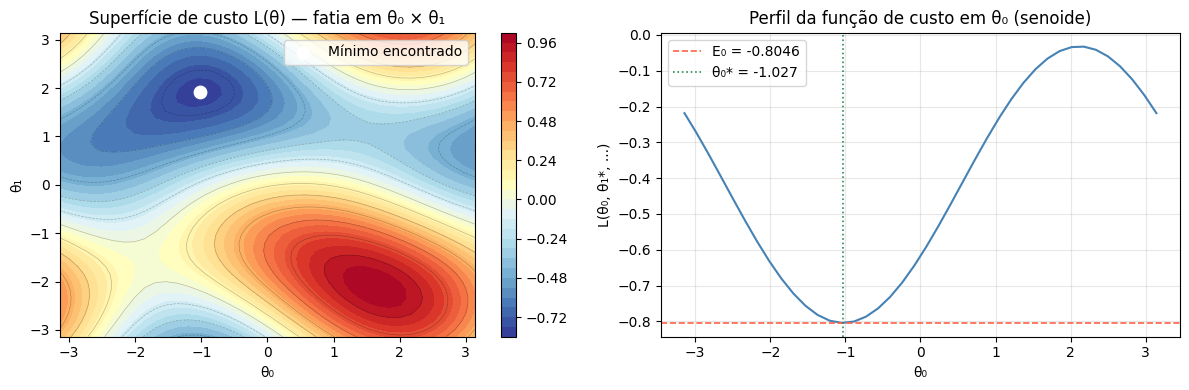

In [24]:
# Superfície de custo: variamos θ₀ e θ₁, fixamos os demais nos valores ótimos
n_grid = 40
th0 = np.linspace(-np.pi, np.pi, n_grid)
th1 = np.linspace(-np.pi, np.pi, n_grid)
TH0, TH1 = np.meshgrid(th0, th1)

Z = np.zeros_like(TH0)
for i in range(n_grid):
    for j in range(n_grid):
        tv = theta_opt.copy()
        tv[0] = TH0[i, j]
        tv[1] = TH1[i, j]
        Z[i, j] = energy_at(tv)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Heatmap
cf = axes[0].contourf(TH0, TH1, Z, levels=30, cmap='RdYlBu_r')
axes[0].contour(TH0, TH1, Z, levels=15, colors='k', alpha=0.25, linewidths=0.5)
axes[0].scatter([theta_opt[0]], [theta_opt[1]], color='white', s=80, zorder=5, label='Mínimo encontrado')
axes[0].set_xlabel('θ₀'); axes[0].set_ylabel('θ₁')
axes[0].set_title('Superfície de custo L(θ) — fatia em θ₀ × θ₁')
axes[0].legend(); plt.colorbar(cf, ax=axes[0])

# Perfil 1D em θ₀
e_profile = [energy_at(np.concatenate([[t], theta_opt[1:]])) for t in th0]
axes[1].plot(th0, e_profile, color='steelblue', lw=1.5)
axes[1].axhline(E0_exact, color='tomato', ls='--', lw=1.2, label=f'E₀ = {E0_exact:.4f}')
axes[1].axvline(theta_opt[0], color='seagreen', ls=':', lw=1.2, label=f'θ₀* = {theta_opt[0]:.3f}')
axes[1].set_xlabel('θ₀'); axes[1].set_ylabel('L(θ₀, θ₁*, ...)')
axes[1].set_title('Perfil da função de custo em θ₀ (senoide)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## Síntese

Esta aula construiu os algoritmos variacionais do princípio ao funcionamento prático.

Partimos do **princípio variacional** $E_0 \leq \langle\psi|H|\psi\rangle$ e sua demonstração, que fundamenta matematicamente por que minimizar valores esperados converge para a energia fundamental. Com isso, estruturamos o VQE como um problema de otimização: encontrar $\theta^* = \arg\min_\theta \langle\psi(\theta)|H|\psi(\theta)\rangle$.

Vimos como **representar hamiltonianos em base de Pauli** — condição necessária para que o Estimator possa calcular valores esperados via circuitos de medição em bases rotacionadas. Implementamos um ansatz hardware-efficient com rotações $R_Y$ e CNOTs, discutindo a escolha de $R_Y$ para estados com amplitudes reais.

A **parameter-shift rule** nos deu gradientes analíticos exatos com custo de $2n$ execuções, sem introduzir aproximações numéricas. Verificamos que os gradientes coincidem com diferenças finitas a oito casas decimais.

No **QAOA**, vimos como a estrutura do circuito é derivada da evolução adiabática: alternar entre o operador de problema $U_C(\gamma) = e^{-i\gamma H_C}$ e o operador mixer $U_B(\beta) = e^{-i\beta H_B}$ é uma discretização do caminho adiabático de $H_B$ para $H_C$. Implementamos o circuito para MaxCut usando a decomposição $e^{i\gamma Z_i Z_j/2} = \text{CNOT} \cdot R_Z \cdot \text{CNOT}$.

Por fim, os **barren plateaus** mostram que expressibilidade e treinabilidade são objetivos conflitantes: ansatze que cobrem bem o espaço de estados têm gradientes exponencialmente pequenos, tornando a otimização impraticável para sistemas grandes. Esse é o principal obstáculo para a escalabilidade de VQAs genéricos.

Os próximos passos naturais são: mitigação de erros aplicada ao VQE (zero-noise extrapolation, probabilistic error cancellation), ansatze motivados quimicamente (UCC para moléculas), e execução em hardware real via Qiskit Runtime com sessões e primitivas autenticadas.